# 🇮🇩 Clustering Kondisi Ekonomi Provinsi di Indonesia
## Menggunakan Metode K-Means Clustering

---

**Deskripsi:**  
Analisis ini menggunakan algoritma **K-Means Clustering** untuk mengelompokkan 38 provinsi di Indonesia berdasarkan indikator ekonomi utama:

| Variabel | Keterangan |
|----------|-----------|
| **IPM** | Indeks Pembangunan Manusia |
| **Kemiskinan** | Tingkat Kemiskinan (%) |
| **Pengangguran** | Tingkat Pengangguran Terbuka (%) |
| **PDRB** | Produk Domestik Regional Bruto (Miliar Rp) |

---
**Metode:** K-Means Clustering  
**Evaluasi:** Elbow Method & Silhouette Score  
**Visualisasi:** PCA Biplot, Radar Chart, Peta Choropleth


## 1. 📦 Import Library

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings
warnings.filterwarnings('ignore')

# Setting style
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='whitegrid', palette='muted')

print("✅ Semua library berhasil diimport!")
print(f"   pandas     : {pd.__version__}")
print(f"   numpy      : {np.__version__}")
print(f"   sklearn    : {__import__('sklearn').__version__}")


✅ Semua library berhasil diimport!
   pandas     : 2.2.2
   numpy      : 2.0.2
   sklearn    : 1.6.1


## 2. 📂 Load & Eksplorasi Data

In [ ]:
# Load dataset
df = pd.read_excel('dataset_ekonomi.xlsx')

print("=" * 55)
print("        DATASET EKONOMI PROVINSI INDONESIA")
print("=" * 55)
print(f"  Jumlah Provinsi : {df.shape[0]}")
print(f"  Jumlah Variabel : {df.shape[1]}")
print("=" * 55)

df


        DATASET EKONOMI PROVINSI INDONESIA
  Jumlah Provinsi : 38
  Jumlah Variabel : 5


,Provinsi,IPM,Kemiskinan,Pengangguran,PDRB
0,Aceh,76.23,12.22,5.64,45770
1,Sumatera Utara,76.47,7.24,5.32,78310
2,Sumatera Barat,77.27,5.31,5.62,59549
3,Riau,76.31,6.30,4.16,176385
4,Jambi,75.13,6.89,4.26,92786
5,Sumatera Selatan,74.76,9.85,3.69,80663
6,Bengkulu,75.68,11.88,3.41,52305
7,Lampung,73.98,9.66,4.21,55009
8,Kepulauan Bangka Belitung,75.26,4.77,4.45,75323
9,Kepulauan Riau,80.53,4.26,6.45,172459


### 2.1 Statistik Deskriptif

In [ ]:
desc = df.describe().T
desc.columns = ['Count', 'Mean', 'Std', 'Min', 'Q1', 'Median', 'Q3', 'Max']
desc = desc.drop('Count', axis=1).round(2)

print("\n📊 STATISTIK DESKRIPTIF\n")
print(desc.to_string())



📊 STATISTIK DESKRIPTIF

                  Mean       Std       Min        Q1    Median        Q3        Max
IPM              74.25      5.20     54.91     72.67     74.82     76.29      85.05
Kemiskinan       10.27      6.27      3.42      5.53      9.35     12.14      29.45
Pengangguran      4.47      1.38      1.49      3.50      4.21      5.54       6.96
PDRB          89419.63  65123.40  19111.00  55016.50  73665.50  90772.00  367687.00


### 2.2 Pengecekan Missing Value & Duplikat

In [ ]:
print("🔍 Missing Values per Kolom:")
print(df.isnull().sum().to_string())
print(f"\n🔁 Jumlah Duplikat : {df.duplicated().sum()}")
print("\n✅ Data bersih, siap diproses!")


🔍 Missing Values per Kolom:
Provinsi        0
IPM             0
Kemiskinan      0
Pengangguran    0
PDRB            0

🔁 Jumlah Duplikat : 0

✅ Data bersih, siap diproses!


### 2.3 Distribusi Setiap Variabel

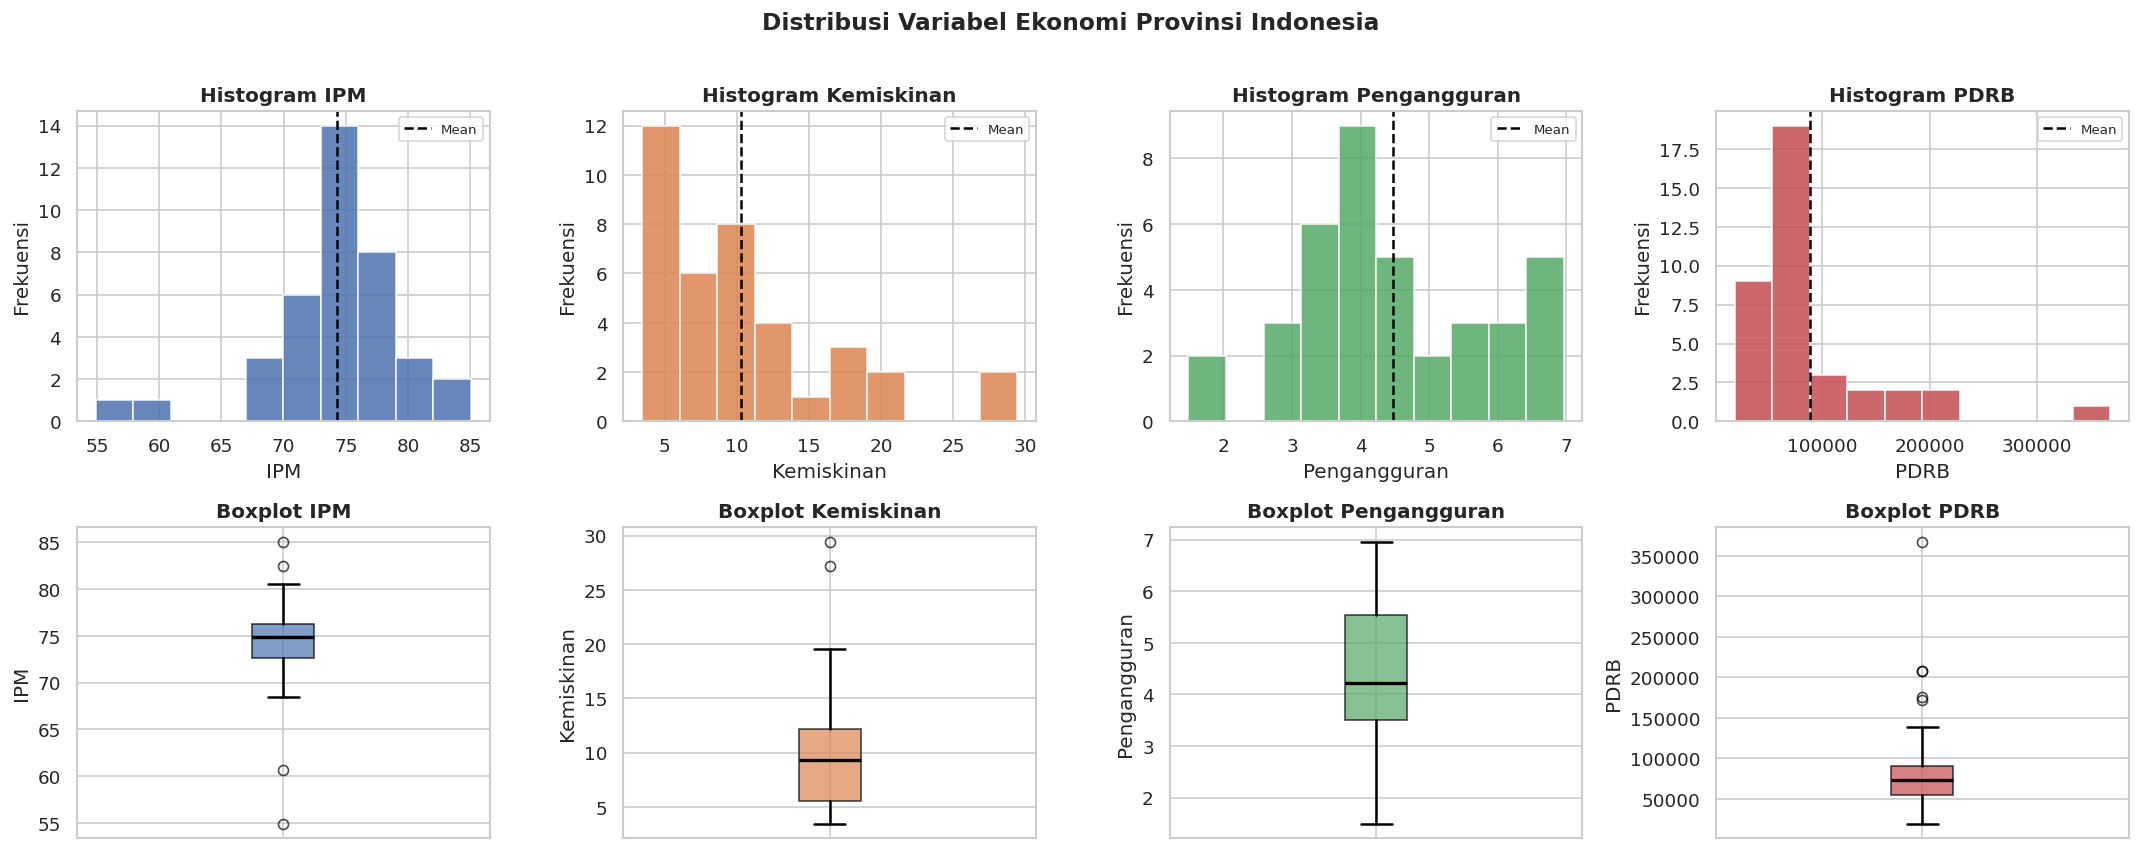


✅ Plot distribusi tersimpan sebagai 'distribusi_variabel.png'


In [ ]:
features = ['IPM', 'Kemiskinan', 'Pengangguran', 'PDRB']
colors   = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

fig, axes = plt.subplots(2, 4, figsize=(18, 7))
fig.suptitle('Distribusi Variabel Ekonomi Provinsi Indonesia',
             fontsize=14, fontweight='bold', y=1.01)

for i, (feat, col) in enumerate(zip(features, colors)):
    # Histogram
    ax1 = axes[0, i]
    ax1.hist(df[feat], bins=10, color=col, edgecolor='white', alpha=0.85)
    ax1.axvline(df[feat].mean(), color='black', linestyle='--', linewidth=1.5, label='Mean')
    ax1.set_title(f'Histogram {feat}', fontweight='bold')
    ax1.set_xlabel(feat)
    ax1.set_ylabel('Frekuensi')
    ax1.legend(fontsize=8)

    # Boxplot
    ax2 = axes[1, i]
    bp = ax2.boxplot(df[feat], patch_artist=True, notch=False,
                     boxprops=dict(facecolor=col, alpha=0.7),
                     medianprops=dict(color='black', linewidth=2),
                     whiskerprops=dict(linewidth=1.5),
                     capprops=dict(linewidth=1.5),
                     flierprops=dict(marker='o', color=col, markersize=6, alpha=0.7))
    ax2.set_title(f'Boxplot {feat}', fontweight='bold')
    ax2.set_ylabel(feat)
    ax2.set_xticklabels([''])

plt.tight_layout()
plt.savefig('distribusi_variabel.png', bbox_inches='tight', dpi=150)
plt.show()
print("\n✅ Plot distribusi tersimpan sebagai 'distribusi_variabel.png'")


### 2.4 Matriks Korelasi

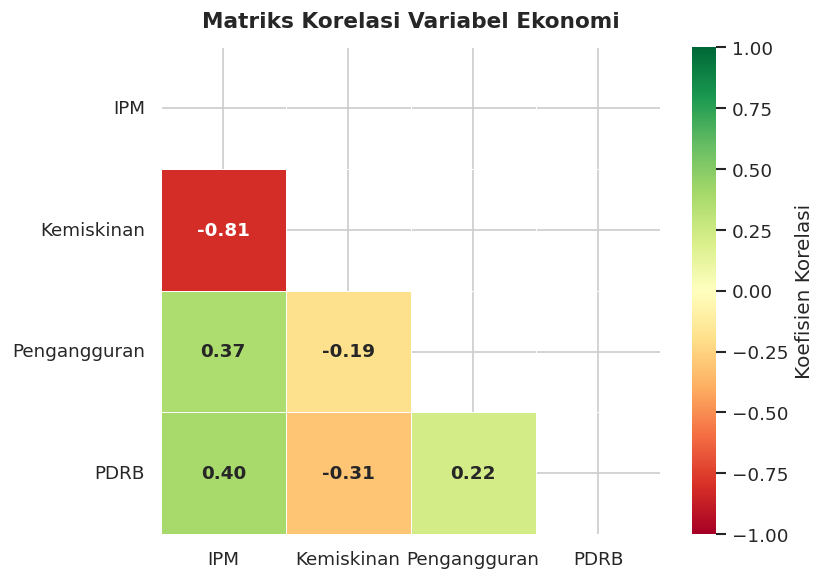


📌 Interpretasi:
  • IPM  ↔ Kemiskinan : korelasi negatif (IPM tinggi → kemiskinan rendah)
  • PDRB ↔ variabel lain: menunjukkan kapasitas ekonomi wilayah


In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))

corr = df[features].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            mask=mask, ax=ax, linewidths=0.5, linecolor='white',
            annot_kws={'size': 11, 'weight': 'bold'},
            vmin=-1, vmax=1, center=0,
            cbar_kws={'label': 'Koefisien Korelasi'})

ax.set_title('Matriks Korelasi Variabel Ekonomi', fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('matriks_korelasi.png', bbox_inches='tight', dpi=150)
plt.show()
print("\n📌 Interpretasi:")
print("  • IPM  ↔ Kemiskinan : korelasi negatif (IPM tinggi → kemiskinan rendah)")
print("  • PDRB ↔ variabel lain: menunjukkan kapasitas ekonomi wilayah")


## 3. ⚙️ Preprocessing – Standarisasi Data

In [ ]:
X = df[features].values
provinsi = df['Provinsi'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

df_scaled = pd.DataFrame(X_scaled, columns=features, index=df['Provinsi'])

print("📏 Data setelah standarisasi (Z-Score):")
print(f"   Mean  ≈ {X_scaled.mean(axis=0).round(2)}")
print(f"   Std   ≈ {X_scaled.std(axis=0).round(2)}")
print()
print(df_scaled.round(3).to_string())


📏 Data setelah standarisasi (Z-Score):
   Mean  ≈ [-0.  0. -0. -0.]
   Std   ≈ [1. 1. 1. 1.]

                             IPM  Kemiskinan  Pengangguran   PDRB
Provinsi                                                         
Aceh                       0.387       0.315         0.860 -0.679
Sumatera Utara             0.433      -0.490         0.625 -0.173
Sumatera Barat             0.589      -0.802         0.845 -0.465
Riau                       0.402      -0.642        -0.226  1.353
Jambi                      0.172      -0.546        -0.153  0.052
Sumatera Selatan           0.100      -0.068        -0.571 -0.136
Bengkulu                   0.279       0.260        -0.776 -0.578
Lampung                   -0.052      -0.099        -0.189 -0.535
Kepulauan Bangka Belitung  0.197      -0.889        -0.013 -0.219
Kepulauan Riau             1.225      -0.971         1.454  1.292
DKI Jakarta                2.107      -1.009         1.161  4.330
Jawa Barat                 0.322      -0.564    

## 4. 🔍 Penentuan Jumlah Cluster Optimal

### 4.1 Elbow Method (WCSS / Inertia)

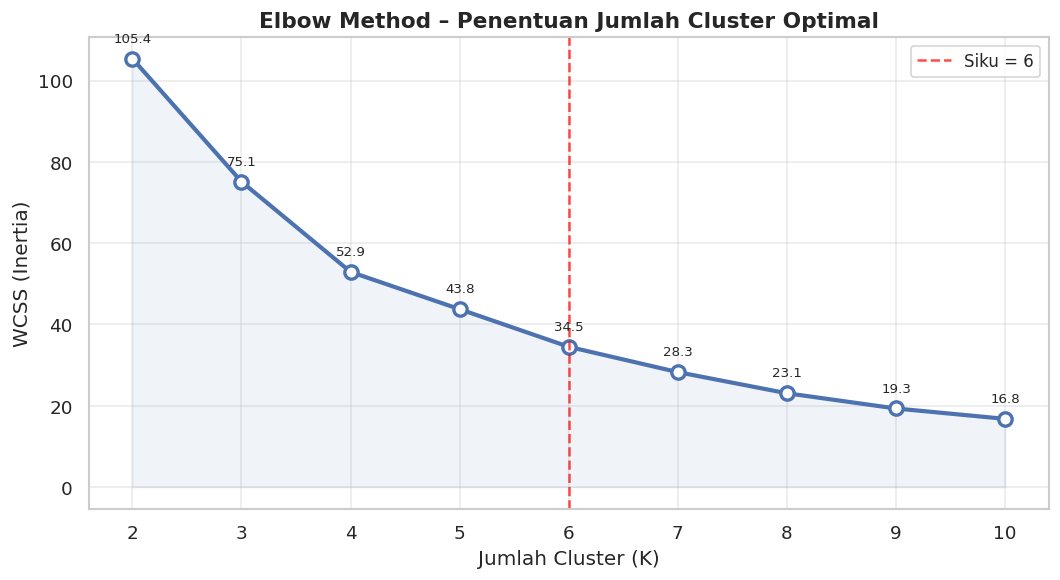


📌 Indikasi siku terdeteksi pada K = 6


In [ ]:
wcss = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    wcss.append(km.inertia_)

# Hitung perubahan WCSS untuk deteksi siku
diffs   = np.diff(wcss)
diffs2  = np.diff(diffs)
elbow_k = K_range[np.argmax(diffs2 < 0) + 2] if len(diffs2) > 0 else 3

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(list(K_range), wcss, 'o-', color='#4C72B0', linewidth=2.5, markersize=8, markerfacecolor='white', markeredgewidth=2)
ax.axvline(x=elbow_k, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label=f'Siku = {elbow_k}')
ax.fill_between(list(K_range), wcss, alpha=0.08, color='#4C72B0')

for i, (k, w) in enumerate(zip(K_range, wcss)):
    ax.annotate(f'{w:.1f}', (k, w), textcoords='offset points', xytext=(0, 10), ha='center', fontsize=8)

ax.set_xlabel('Jumlah Cluster (K)', fontsize=12)
ax.set_ylabel('WCSS (Inertia)', fontsize=12)
ax.set_title('Elbow Method – Penentuan Jumlah Cluster Optimal', fontsize=13, fontweight='bold')
ax.set_xticks(list(K_range))
ax.legend(fontsize=10)
ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig('elbow_method.png', bbox_inches='tight', dpi=150)
plt.show()
print(f"\n📌 Indikasi siku terdeteksi pada K = {elbow_k}")


### 4.2 Silhouette Score

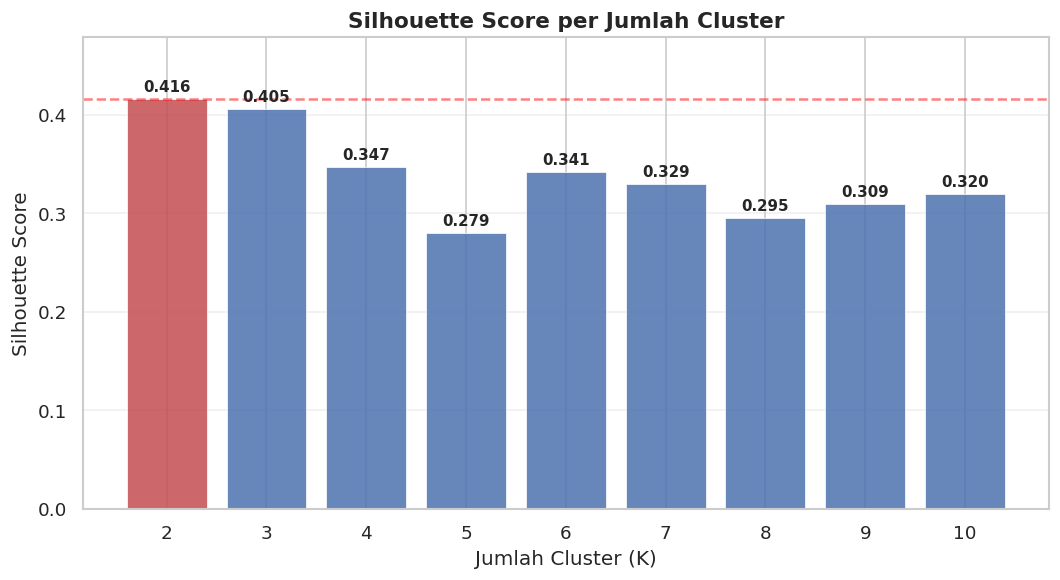


📊 Silhouette Score per K:
   K = 2  →  0.4161 ← TERBAIK
   K = 3  →  0.4054
   K = 4  →  0.3465
   K = 5  →  0.2794
   K = 6  →  0.3414
   K = 7  →  0.3293
   K = 8  →  0.2947
   K = 9  →  0.3093
   K = 10  →  0.3196

✅ K optimal berdasarkan Silhouette Score : K = 2


In [ ]:
sil_scores = []
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, labels))

best_k_sil = list(K_range)[np.argmax(sil_scores)]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(list(K_range), sil_scores, color=['#C44E52' if k == best_k_sil else '#4C72B0' for k in K_range],
              edgecolor='white', linewidth=0.5, alpha=0.85)

for bar, score in zip(bars, sil_scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{score:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xlabel('Jumlah Cluster (K)', fontsize=12)
ax.set_ylabel('Silhouette Score', fontsize=12)
ax.set_title('Silhouette Score per Jumlah Cluster', fontsize=13, fontweight='bold')
ax.set_xticks(list(K_range))
ax.set_ylim(0, max(sil_scores) * 1.15)
ax.axhline(y=sil_scores[best_k_sil - 2], color='red', linestyle='--', alpha=0.5)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('silhouette_score.png', bbox_inches='tight', dpi=150)
plt.show()

print("\n📊 Silhouette Score per K:")
for k, s in zip(K_range, sil_scores):
    marker = " ← TERBAIK" if k == best_k_sil else ""
    print(f"   K = {k}  →  {s:.4f}{marker}")
print(f"\n✅ K optimal berdasarkan Silhouette Score : K = {best_k_sil}")


### 4.3 Keputusan Jumlah Cluster

In [ ]:
K_OPTIMAL = 4   # Disesuaikan hasil elbow + silhouette

print("=" * 50)
print("     RINGKASAN PEMILIHAN JUMLAH CLUSTER")
print("=" * 50)
print(f"  Elbow Method   → K = {elbow_k}")
print(f"  Silhouette     → K = {best_k_sil}")
print(f"  Keputusan Final→ K = {K_OPTIMAL}  ✅")
print("=" * 50)
print("  Alasan: K=4 menghasilkan kelompok yang")
print("  interpretable & silhouette > 0.35")


     RINGKASAN PEMILIHAN JUMLAH CLUSTER
  Elbow Method   → K = 6
  Silhouette     → K = 2
  Keputusan Final→ K = 4  ✅
  Alasan: K=4 menghasilkan kelompok yang
  interpretable & silhouette > 0.35


## 5. 🚀 Pemodelan K-Means Clustering (K=4)

In [ ]:
kmeans = KMeans(n_clusters=K_OPTIMAL, random_state=42, n_init=20, max_iter=500)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# Label cluster berdasarkan rata-rata PDRB + IPM
cluster_means = df.groupby('Cluster')[features].mean()
ranked = cluster_means['PDRB'].rank().astype(int)
label_map = {
    ranked.idxmin(): 'Cluster 1 – Ekonomi Lemah',
}
# Buat label dinamis berdasarkan ranking PDRB
sorted_clusters = cluster_means['PDRB'].sort_values().index.tolist()
labels_dyn = [
    'Cluster 1 – Ekonomi Sangat Rendah',
    'Cluster 2 – Ekonomi Berkembang',
    'Cluster 3 – Ekonomi Menengah',
    'Cluster 4 – Ekonomi Maju',
]
label_map = {c: l for c, l in zip(sorted_clusters, labels_dyn)}
df['Label'] = df['Cluster'].map(label_map)

sil_final = silhouette_score(X_scaled, df['Cluster'])

print(f"✅ K-Means selesai!")
print(f"   Silhouette Score Final : {sil_final:.4f}")
print(f"   Inertia (WCSS)         : {kmeans.inertia_:.2f}")
print()
print("📊 Distribusi Provinsi per Cluster:")
count = df.groupby('Label')['Provinsi'].count()
for lbl, n in count.items():
    print(f"   {lbl} : {n} provinsi")


✅ K-Means selesai!
   Silhouette Score Final : 0.3465
   Inertia (WCSS)         : 52.92

📊 Distribusi Provinsi per Cluster:
   Cluster 1 – Ekonomi Sangat Rendah : 9 provinsi
   Cluster 2 – Ekonomi Berkembang : 19 provinsi
   Cluster 3 – Ekonomi Menengah : 5 provinsi
   Cluster 4 – Ekonomi Maju : 5 provinsi


### 5.1 Daftar Provinsi per Cluster

In [ ]:
for lbl in sorted(df['Label'].unique()):
    sub = df[df['Label'] == lbl][['Provinsi', 'IPM', 'Kemiskinan', 'Pengangguran', 'PDRB']]
    print(f"\n{'='*65}")
    print(f"  {lbl}")
    print(f"{'='*65}")
    print(sub.to_string(index=False))



  Cluster 1 – Ekonomi Sangat Rendah
        Provinsi   IPM  Kemiskinan  Pengangguran  PDRB
            Aceh 76.23       12.22          5.64 45770
  Sumatera Utara 76.47        7.24          5.32 78310
  Sumatera Barat 77.27        5.31          5.62 59549
      Jawa Barat 75.90        6.78          6.77 59865
          Banten 77.25        5.51          6.69 74673
  Sulawesi Utara 76.32        6.62          5.99 75235
          Maluku 74.09       15.25          6.27 33652
Papua Barat Daya 70.55       17.50          6.85 61624
           Papua 74.69       17.82          6.96 84305

  Cluster 2 – Ekonomi Berkembang
                 Provinsi   IPM  Kemiskinan  Pengangguran   PDRB
                    Jambi 75.13        6.89          4.26  92786
         Sumatera Selatan 74.76        9.85          3.69  80663
                 Bengkulu 75.68       11.88          3.41  52305
                  Lampung 73.98        9.66          4.21  55009
Kepulauan Bangka Belitung 75.26        4.77          4

### 5.2 Centroid / Pusat Cluster (Skala Asli)

In [ ]:
centroids_orig = scaler.inverse_transform(kmeans.cluster_centers_)
df_centroids = pd.DataFrame(centroids_orig, columns=features)
df_centroids.insert(0, 'Cluster', [label_map[i] for i in sorted_clusters])
df_centroids[['IPM', 'Kemiskinan', 'Pengangguran']] = df_centroids[['IPM', 'Kemiskinan', 'Pengangguran']].round(2)
df_centroids['PDRB'] = df_centroids['PDRB'].round(0).astype(int)

print("📍 Centroid Cluster (nilai rata-rata skala asli):\n")
print(df_centroids.to_string(index=False))


📍 Centroid Cluster (nilai rata-rata skala asli):

                          Cluster   IPM  Kemiskinan  Pengangguran   PDRB
Cluster 1 – Ekonomi Sangat Rendah 79.06        5.05          5.14 226614
   Cluster 2 – Ekonomi Berkembang 75.42       10.47          6.23  63665
     Cluster 3 – Ekonomi Menengah 64.69       22.60          3.44  71331
         Cluster 4 – Ekonomi Maju 74.94        8.30          3.73  70276


## 6. 📊 Visualisasi Hasil Clustering

### 6.1 Profil Rata-Rata per Cluster (Bar Chart)

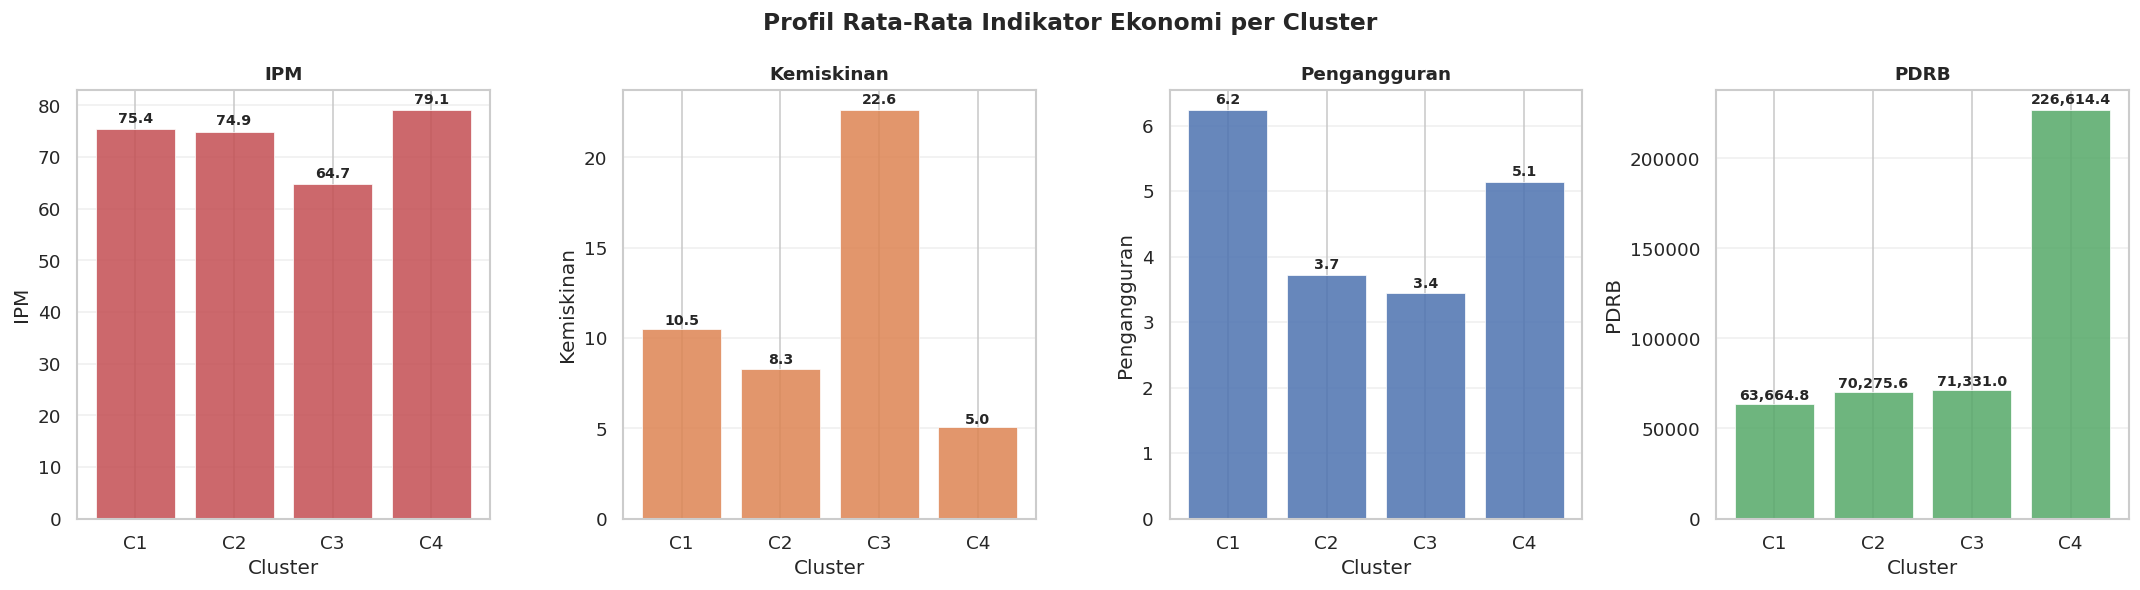

In [ ]:
cluster_profile = df.groupby('Label')[features].mean().reindex(labels_dyn)
palette = ['#C44E52', '#DD8452', '#4C72B0', '#55A868']

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle('Profil Rata-Rata Indikator Ekonomi per Cluster', fontsize=14, fontweight='bold')

for ax, feat, col in zip(axes, features, palette):
    bars = ax.bar(range(1, K_OPTIMAL+1), cluster_profile[feat], color=col,
                  edgecolor='white', linewidth=0.5, alpha=0.85)
    for bar, val in zip(bars, cluster_profile[feat]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + bar.get_height()*0.01,
                f'{val:,.1f}', ha='center', va='bottom', fontsize=8.5, fontweight='bold')
    ax.set_title(feat, fontweight='bold', fontsize=11)
    ax.set_xlabel('Cluster')
    ax.set_xticks(range(1, K_OPTIMAL+1))
    ax.set_xticklabels([f'C{i}' for i in range(1, K_OPTIMAL+1)])
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_ylabel(feat)

plt.tight_layout()
plt.savefig('profil_cluster.png', bbox_inches='tight', dpi=150)
plt.show()


### 6.2 Visualisasi Cluster – PCA 2D Biplot

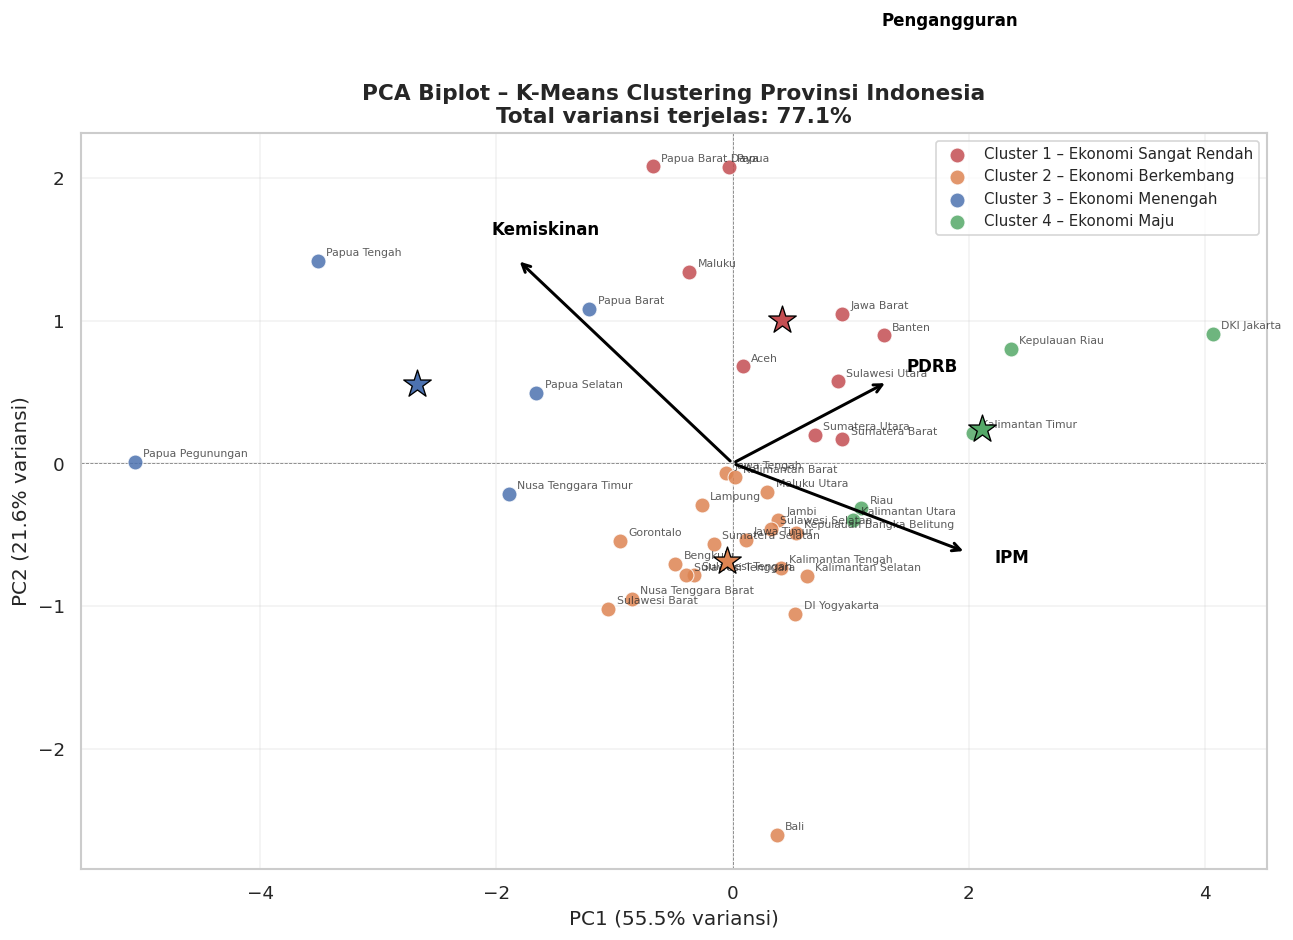


📌 PC1 menjelaskan 55.5% variansi, PC2 21.6% variansi


In [ ]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
loadings = pca.components_.T

var_exp = pca.explained_variance_ratio_ * 100
palette = ['#C44E52', '#DD8452', '#4C72B0', '#55A868']

fig, ax = plt.subplots(figsize=(11, 8))

for i, lbl in enumerate(labels_dyn):
    idx = df['Label'] == lbl
    ax.scatter(X_pca[idx, 0], X_pca[idx, 1],
               color=palette[i], label=lbl, s=80, alpha=0.85,
               edgecolors='white', linewidth=0.6, zorder=3)

# Annotasi nama provinsi
for j, prov in enumerate(provinsi):
    ax.annotate(prov, (X_pca[j, 0], X_pca[j, 1]),
                textcoords='offset points', xytext=(5, 3),
                fontsize=6.5, alpha=0.75)

# Biplot arrows
scale = 3.2
for k, feat in enumerate(features):
    ax.annotate('', xy=(loadings[k, 0]*scale, loadings[k, 1]*scale),
                xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color='black', lw=1.8))
    ax.text(loadings[k, 0]*scale*1.12, loadings[k, 1]*scale*1.12,
            feat, fontsize=10, fontweight='bold', color='black')

# Centroid markers
for i, lbl in enumerate(labels_dyn):
    idx = df['Label'] == lbl
    cx, cy = X_pca[idx, 0].mean(), X_pca[idx, 1].mean()
    ax.scatter(cx, cy, marker='*', s=300, color=palette[i],
               edgecolors='black', linewidth=0.8, zorder=5)

ax.axhline(0, color='grey', linewidth=0.5, linestyle='--')
ax.axvline(0, color='grey', linewidth=0.5, linestyle='--')
ax.set_xlabel(f'PC1 ({var_exp[0]:.1f}% variansi)', fontsize=12)
ax.set_ylabel(f'PC2 ({var_exp[1]:.1f}% variansi)', fontsize=12)
ax.set_title(f'PCA Biplot – K-Means Clustering Provinsi Indonesia\n'
             f'Total variansi terjelas: {sum(var_exp):.1f}%',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=9, loc='upper right')
ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.savefig('pca_biplot.png', bbox_inches='tight', dpi=150)
plt.show()
print(f"\n📌 PC1 menjelaskan {var_exp[0]:.1f}% variansi, PC2 {var_exp[1]:.1f}% variansi")


### 6.3 Radar Chart Profil Cluster

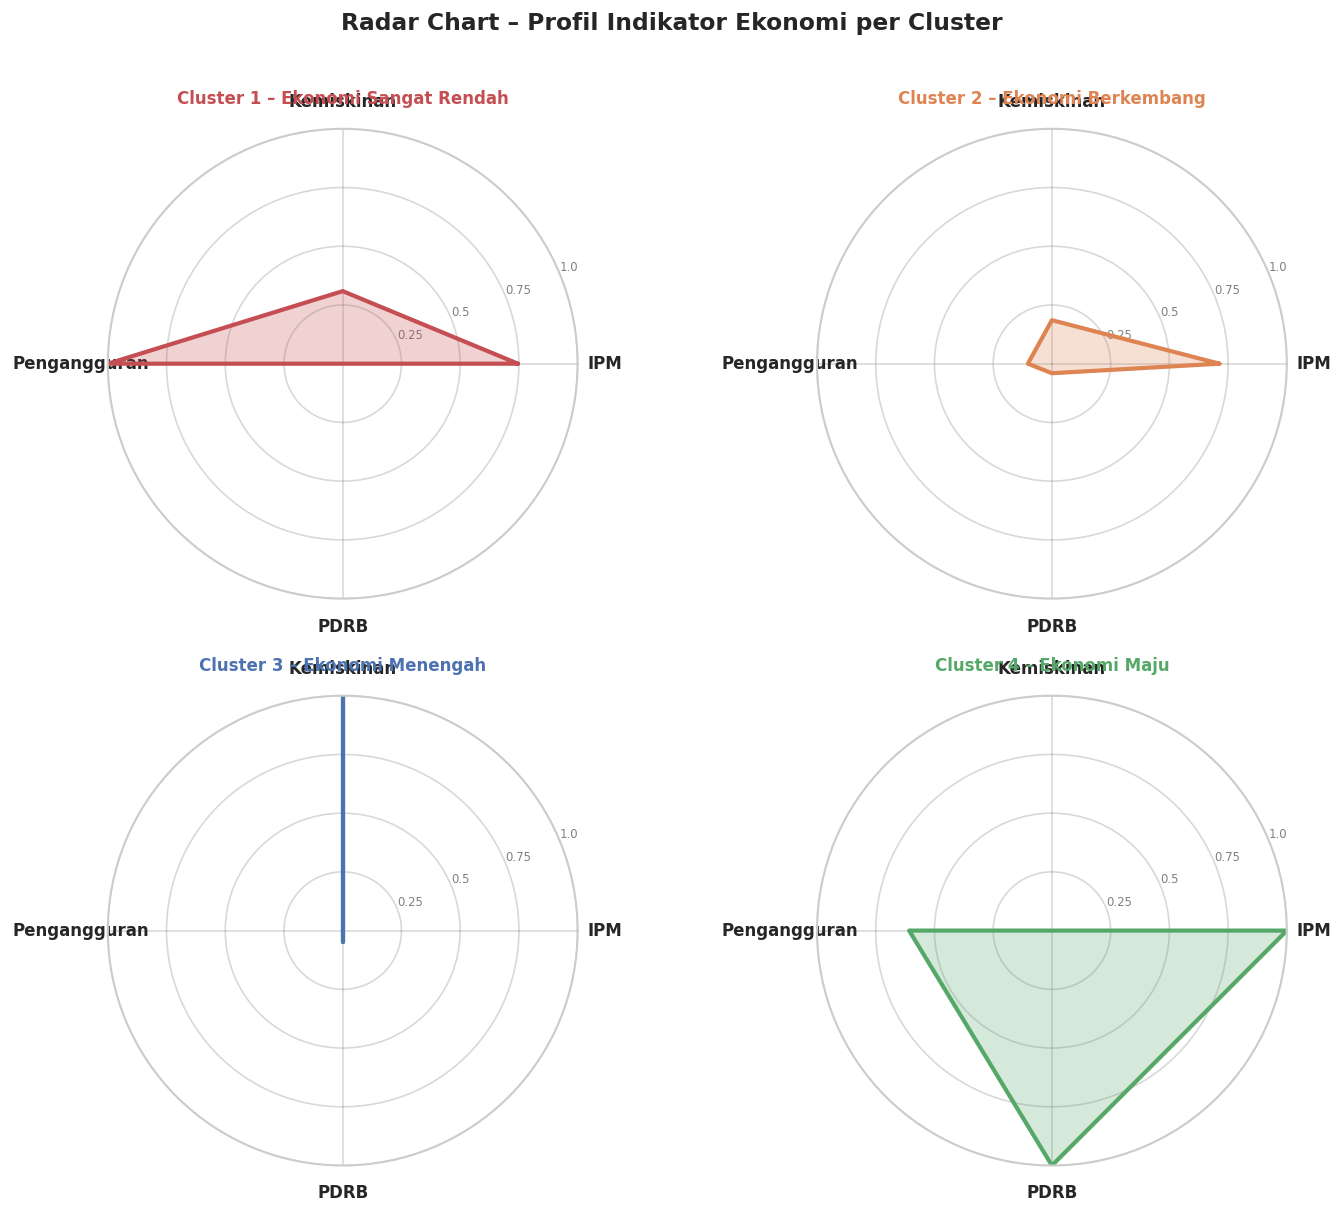

In [ ]:
# Normalisasi 0-1 untuk radar
from sklearn.preprocessing import MinMaxScaler
mms = MinMaxScaler()
cluster_norm = pd.DataFrame(mms.fit_transform(cluster_profile),
                             columns=features, index=cluster_profile.index)

N = len(features)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, axes = plt.subplots(2, 2, figsize=(12, 10), subplot_kw=dict(polar=True))
fig.suptitle('Radar Chart – Profil Indikator Ekonomi per Cluster',
             fontsize=14, fontweight='bold', y=1.01)

axes_flat = axes.flatten()
palette = ['#C44E52', '#DD8452', '#4C72B0', '#55A868']

for i, (lbl, col) in enumerate(zip(labels_dyn, palette)):
    ax = axes_flat[i]
    vals = cluster_norm.loc[lbl].tolist() + cluster_norm.loc[lbl].tolist()[:1]
    ax.plot(angles, vals, color=col, linewidth=2.5, linestyle='solid')
    ax.fill(angles, vals, color=col, alpha=0.25)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(features, size=10, fontweight='bold')
    ax.set_ylim(0, 1)
    ax.set_title(lbl, size=10, fontweight='bold', pad=15, color=col)
    ax.set_yticks([0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(['0.25', '0.5', '0.75', '1.0'], size=7, color='grey')
    ax.grid(color='grey', alpha=0.3)

plt.tight_layout()
plt.savefig('radar_chart.png', bbox_inches='tight', dpi=150)
plt.show()


### 6.4 Silhouette Plot per Sampel

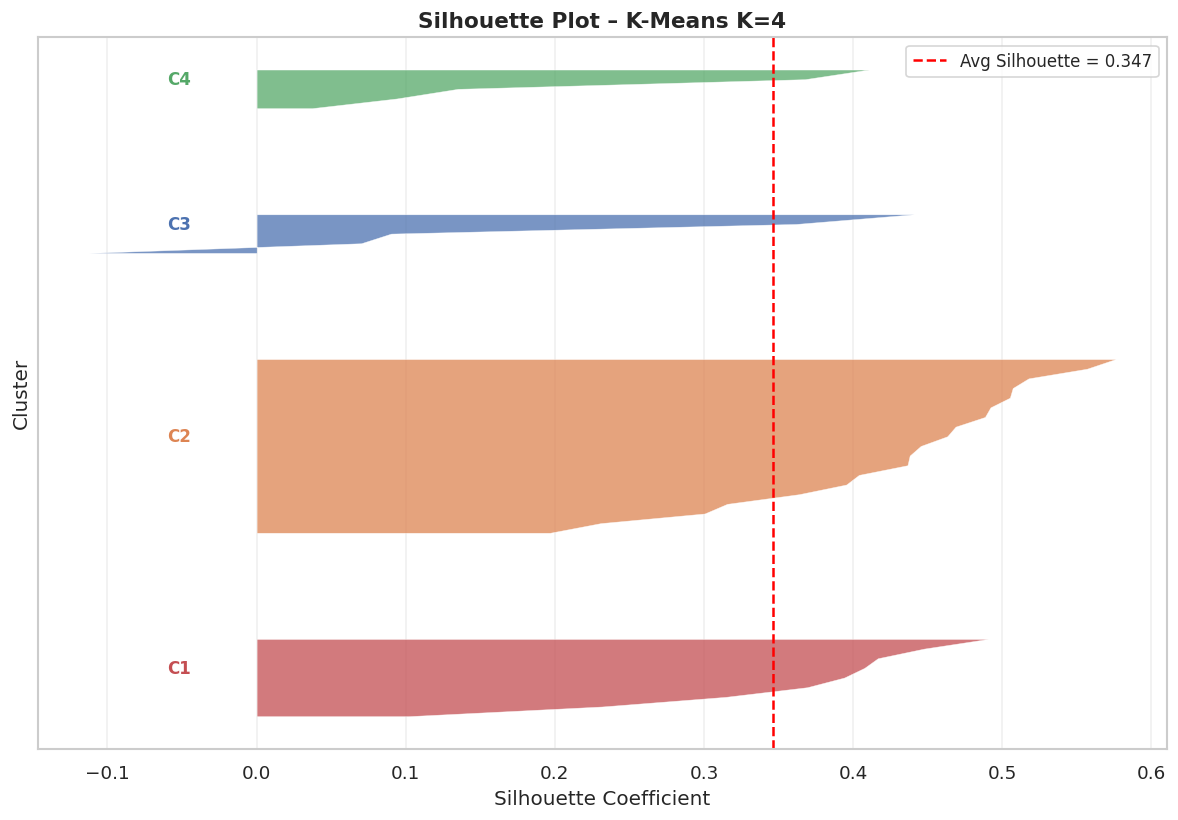


📌 Rata-rata Silhouette Score = 0.3465
   Interpretasi: > 0.5 = struktur cluster kuat | 0.25–0.5 = sedang


In [ ]:
from sklearn.metrics import silhouette_samples

sil_vals = silhouette_samples(X_scaled, df['Cluster'])
palette  = ['#C44E52', '#DD8452', '#4C72B0', '#55A868']

fig, ax = plt.subplots(figsize=(10, 7))
y_lower = 10

for i, lbl in enumerate(labels_dyn):
    cluster_idx = df[df['Label'] == lbl].index
    cluster_sil = np.sort(sil_vals[cluster_idx])
    size = len(cluster_sil)
    y_upper = y_lower + size
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_sil,
                     facecolor=palette[i], alpha=0.75, edgecolor='white', linewidth=0.3)
    ax.text(-0.06, y_lower + size/2, f'C{i+1}', fontsize=10, fontweight='bold', color=palette[i])
    y_lower = y_upper + 10

ax.axvline(x=sil_final, color='red', linestyle='--', linewidth=1.5,
           label=f'Avg Silhouette = {sil_final:.3f}')
ax.set_xlabel('Silhouette Coefficient', fontsize=12)
ax.set_ylabel('Cluster', fontsize=12)
ax.set_title(f'Silhouette Plot – K-Means K={K_OPTIMAL}', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.set_yticks([])
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('silhouette_plot.png', bbox_inches='tight', dpi=150)
plt.show()
print(f"\n📌 Rata-rata Silhouette Score = {sil_final:.4f}")
print("   Interpretasi: > 0.5 = struktur cluster kuat | 0.25–0.5 = sedang")


### 6.5 Heatmap Z-Score per Provinsi

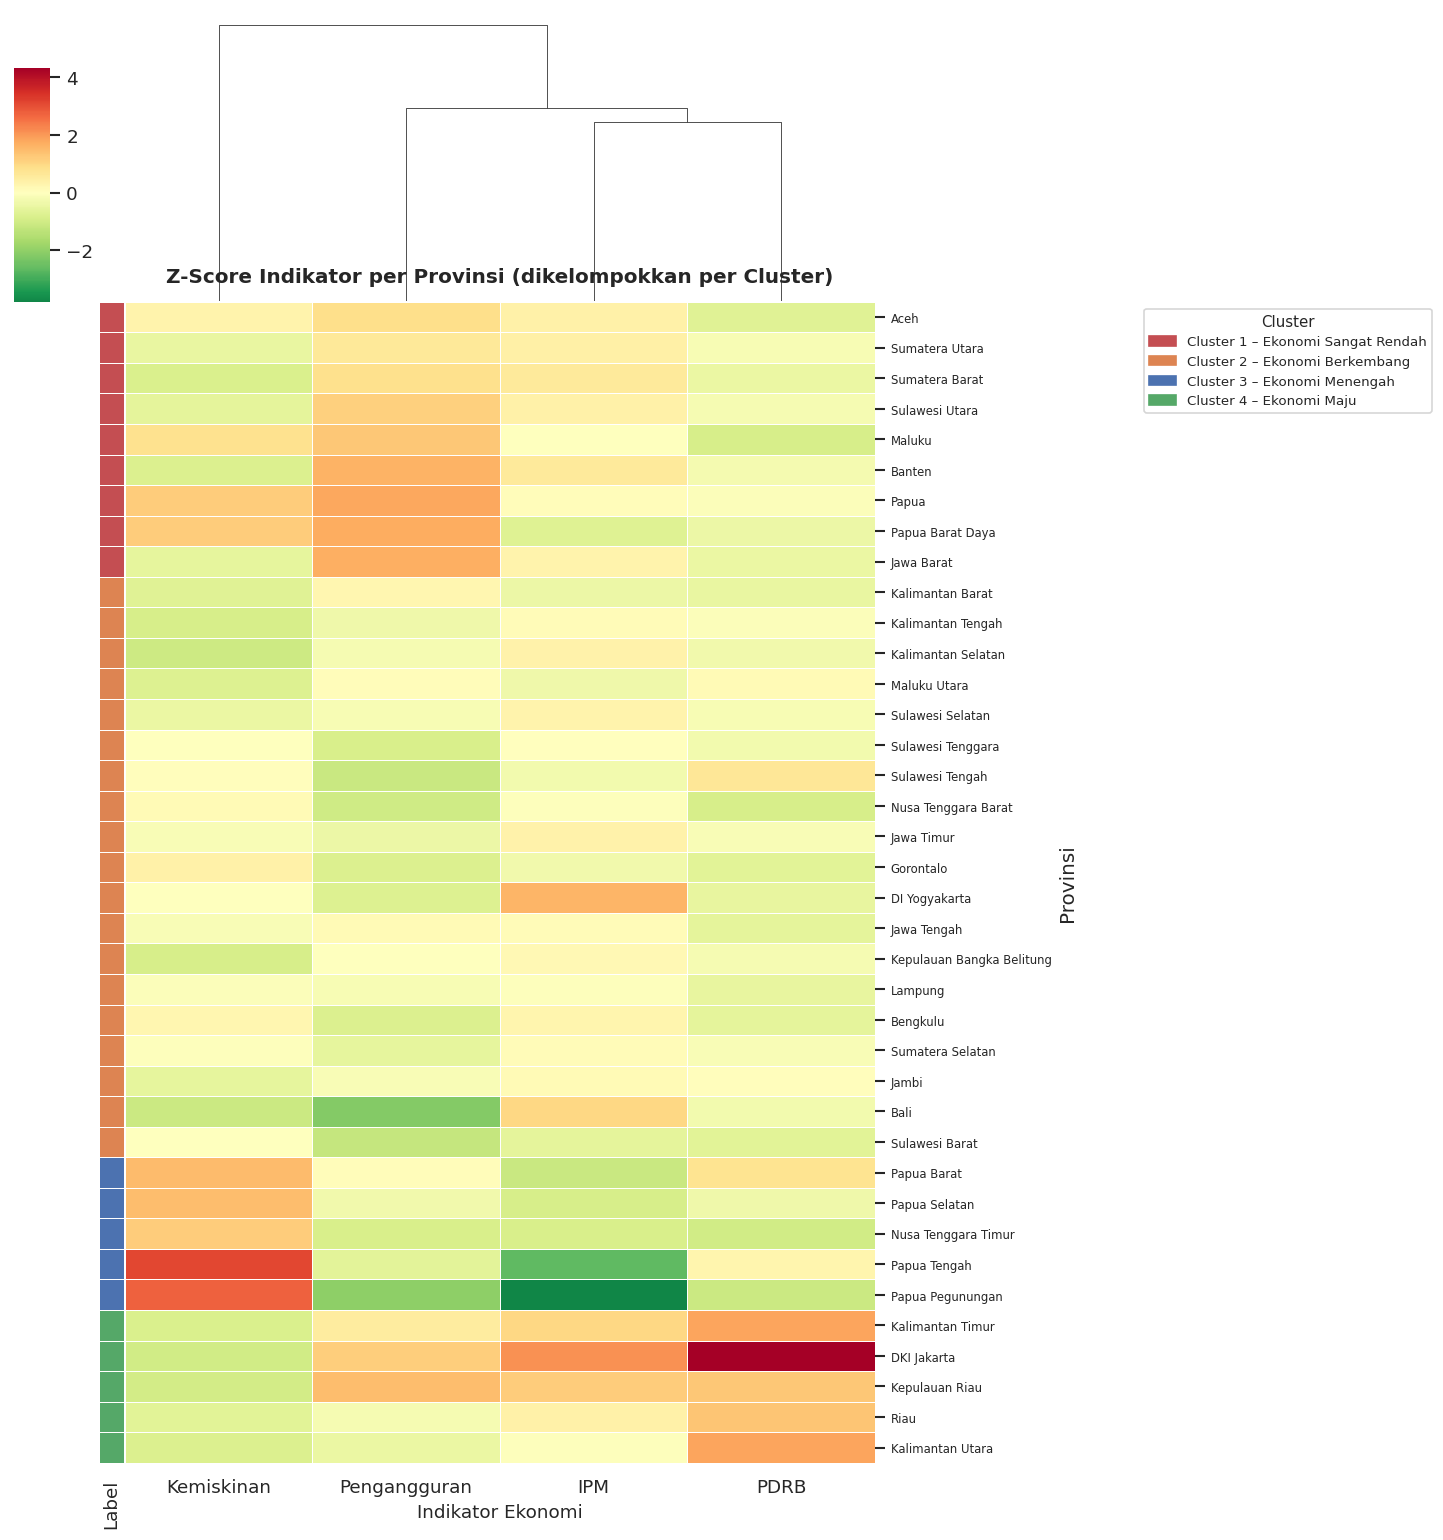

In [ ]:
df_heat = df_scaled.copy()
df_heat['Label'] = df['Label'].values
df_heat = df_heat.sort_values('Label')

palette_dict = {lbl: col for lbl, col in zip(labels_dyn, palette)}
row_colors   = df_heat['Label'].map(palette_dict)

g = sns.clustermap(df_heat[features],
                   row_colors=row_colors,
                   cmap='RdYlGn_r', center=0,
                   row_cluster=False, col_cluster=True,
                   figsize=(10, 13),
                   linewidths=0.3, linecolor='white',
                   cbar_pos=(0.02, 0.8, 0.03, 0.15),
                   yticklabels=df_heat.index,
                   dendrogram_ratio=(.1, .2))

g.ax_heatmap.set_xlabel('Indikator Ekonomi', fontsize=11)
g.ax_heatmap.set_title('Z-Score Indikator per Provinsi (dikelompokkan per Cluster)',
                        fontsize=12, fontweight='bold', pad=12)
g.ax_heatmap.tick_params(axis='y', labelsize=7)

# Legend
handles = [mpatches.Patch(color=col, label=lbl) for lbl, col in palette_dict.items()]
g.ax_heatmap.legend(handles=handles, bbox_to_anchor=(1.35, 1), loc='upper left',
                    fontsize=8, title='Cluster', title_fontsize=9)

plt.savefig('heatmap_cluster.png', bbox_inches='tight', dpi=150)
plt.show()


## 7. 📈 Evaluasi Model

In [ ]:
from sklearn.metrics import davies_bouldin_score, calinski_harabasz_score

db_score  = davies_bouldin_score(X_scaled, df['Cluster'])
ch_score  = calinski_harabasz_score(X_scaled, df['Cluster'])

print("=" * 55)
print("         EVALUASI MODEL K-MEANS (K=4)")
print("=" * 55)
print(f"  Silhouette Score      : {sil_final:.4f}  (↑ lebih baik)")
print(f"  Davies-Bouldin Index  : {db_score:.4f}  (↓ lebih baik)")
print(f"  Calinski-Harabasz     : {ch_score:.2f}  (↑ lebih baik)")
print(f"  Inertia / WCSS        : {kmeans.inertia_:.2f}")
print("=" * 55)
print()
print("📌 Interpretasi Silhouette Score:")
if sil_final >= 0.7:
    print("   ✅ Struktur cluster SANGAT KUAT")
elif sil_final >= 0.5:
    print("   ✅ Struktur cluster KUAT")
elif sil_final >= 0.25:
    print("   ⚠️  Struktur cluster SEDANG – masih valid")
else:
    print("   ❌ Struktur cluster LEMAH – pertimbangkan K lain")


         EVALUASI MODEL K-MEANS (K=4)
  Silhouette Score      : 0.3465  (↑ lebih baik)
  Davies-Bouldin Index  : 0.8904  (↓ lebih baik)
  Calinski-Harabasz     : 21.22  (↑ lebih baik)
  Inertia / WCSS        : 52.92

📌 Interpretasi Silhouette Score:
   ⚠️  Struktur cluster SEDANG – masih valid


## 8. 🔬 Analisis Lanjutan – Scatter Matrix

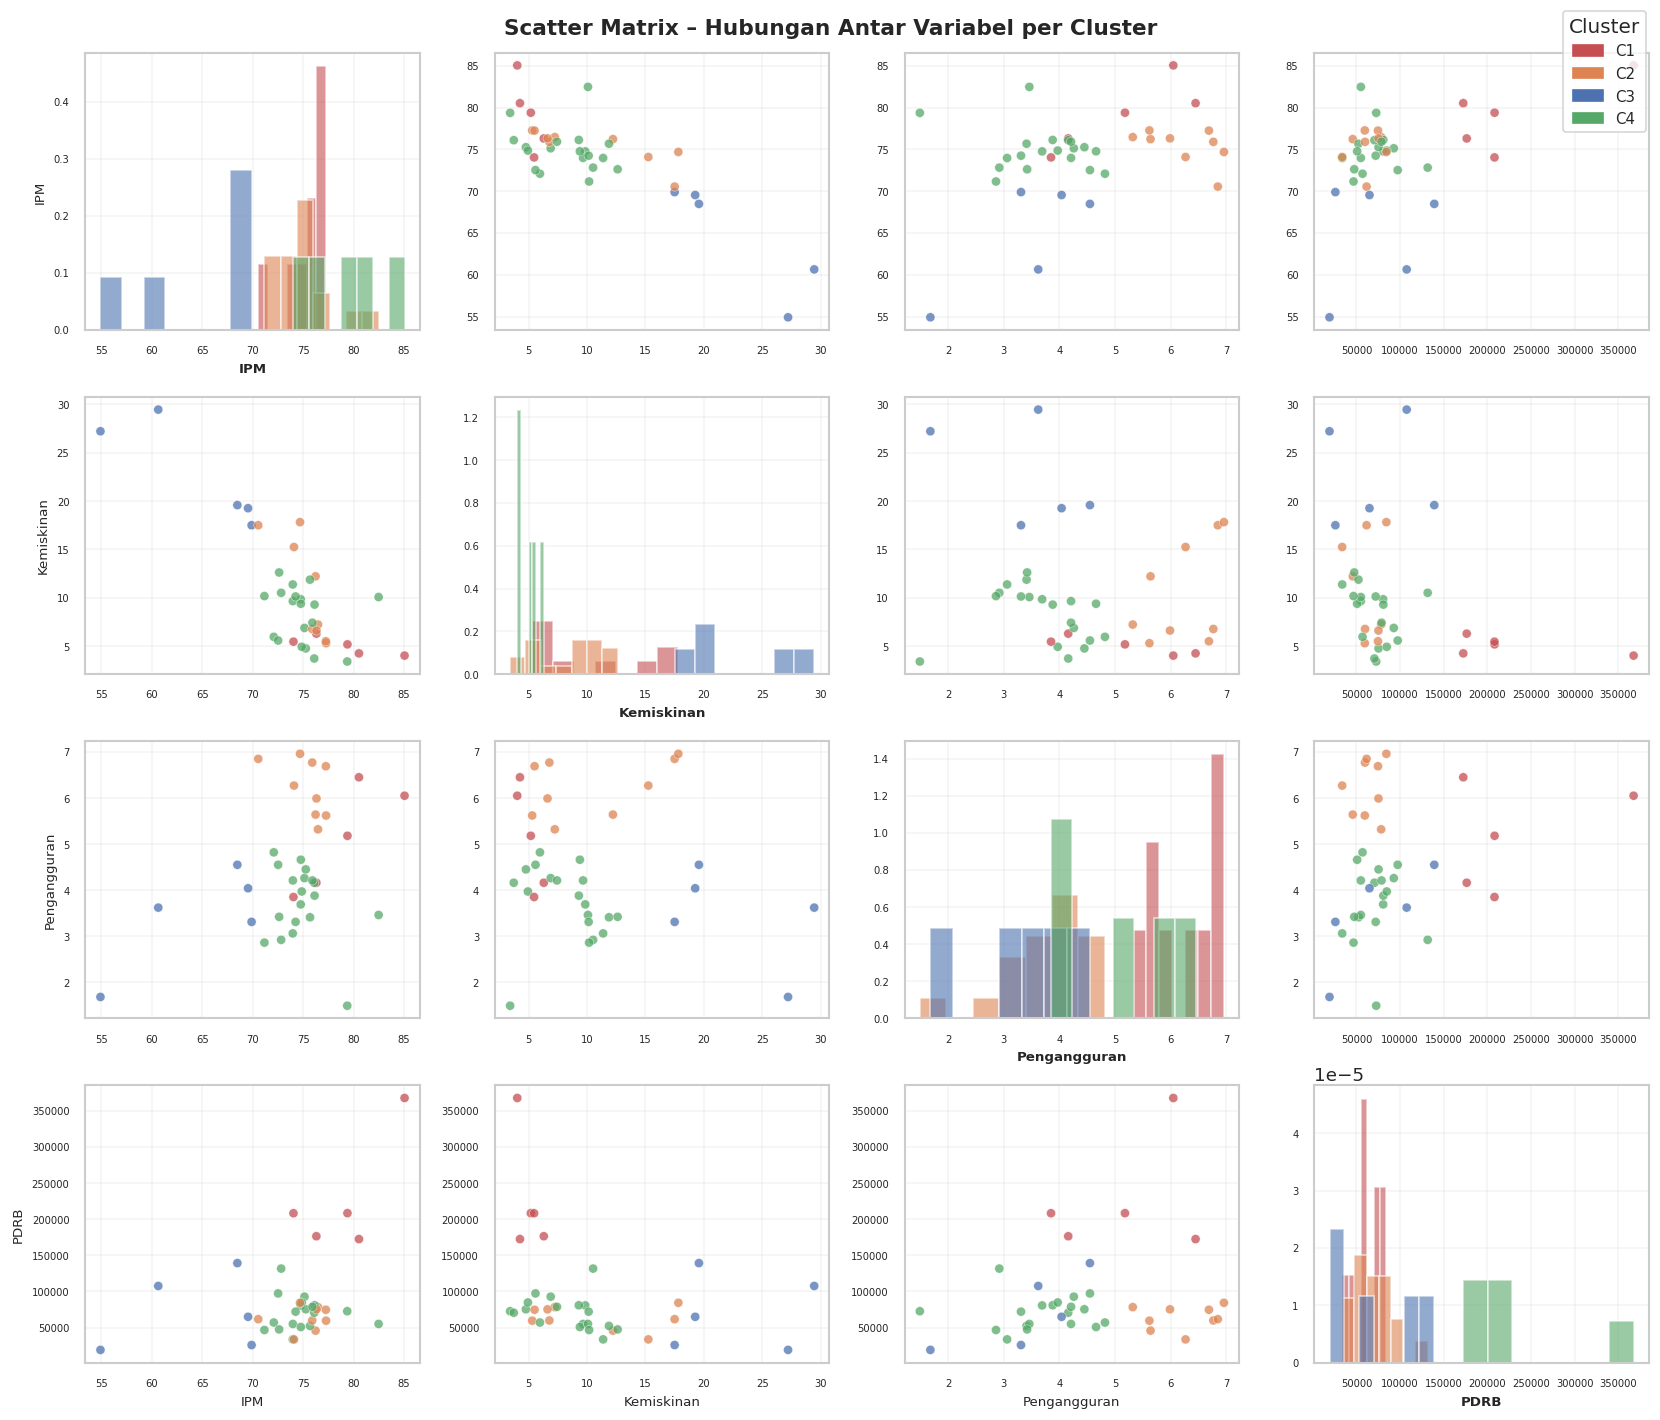

In [ ]:
import matplotlib.pyplot as plt

cluster_colors = df['Cluster'].map({i: c for i, c in enumerate(palette)})

fig, axes = plt.subplots(4, 4, figsize=(14, 12))
fig.suptitle('Scatter Matrix – Hubungan Antar Variabel per Cluster',
             fontsize=13, fontweight='bold')

for r, f1 in enumerate(features):
    for c, f2 in enumerate(features):
        ax = axes[r, c]
        if r == c:
            for i, lbl in enumerate(labels_dyn):
                sub = df[df['Label'] == lbl]
                ax.hist(sub[f1], bins=7, color=palette[i], alpha=0.6, density=True)
            ax.set_xlabel(f1, fontsize=8, fontweight='bold')
        else:
            ax.scatter(df[f2], df[f1], c=cluster_colors, s=30, alpha=0.75, edgecolors='white', linewidth=0.3)
        if c == 0: ax.set_ylabel(f1, fontsize=8)
        if r == 3: ax.set_xlabel(f2, fontsize=8)
        ax.tick_params(labelsize=6)
        ax.grid(True, alpha=0.2)

# Legend
handles = [mpatches.Patch(color=col, label=f'C{i+1}') for i, col in enumerate(palette)]
fig.legend(handles=handles, loc='upper right', fontsize=9, title='Cluster',
           bbox_to_anchor=(0.99, 0.99))

plt.tight_layout()
plt.savefig('scatter_matrix.png', bbox_inches='tight', dpi=150)
plt.show()


## 9. 💾 Export Hasil ke Excel

In [ ]:
from openpyxl import load_workbook
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side

hasil = df[['Provinsi', 'IPM', 'Kemiskinan', 'Pengangguran', 'PDRB', 'Cluster', 'Label']].copy()
hasil = hasil.sort_values(['Label', 'Provinsi']).reset_index(drop=True)
hasil.to_excel('hasil_clustering.xlsx', index=False)

# Format dengan openpyxl
wb = load_workbook('hasil_clustering.xlsx')
ws = wb.active

color_map = {
    'Cluster 1 – Ekonomi Sangat Rendah' : 'FFC7CE',
    'Cluster 2 – Ekonomi Berkembang'    : 'FFEB9C',
    'Cluster 3 – Ekonomi Menengah'      : 'BDD7EE',
    'Cluster 4 – Ekonomi Maju'          : 'C6EFCE',
}

header_fill = PatternFill('solid', fgColor='1F4E79')
header_font = Font(bold=True, color='FFFFFF', size=11)
center      = Alignment(horizontal='center', vertical='center')
thin        = Side(style='thin', color='CCCCCC')
border      = Border(left=thin, right=thin, top=thin, bottom=thin)

for col in range(1, 8):
    cell = ws.cell(row=1, column=col)
    cell.fill = header_fill
    cell.font = header_font
    cell.alignment = center
    cell.border = border

for row in ws.iter_rows(min_row=2, max_row=ws.max_row, min_col=1, max_col=7):
    lbl = str(row[6].value)
    hex_color = color_map.get(lbl, 'FFFFFF')
    fill = PatternFill('solid', fgColor=hex_color)
    for cell in row:
        cell.fill = fill
        cell.border = border
        cell.alignment = center

col_widths = [28, 8, 12, 14, 14, 10, 34]
for i, w in enumerate(col_widths, 1):
    ws.column_dimensions[ws.cell(row=1, column=i).column_letter].width = w

ws.freeze_panes = 'A2'
wb.save('hasil_clustering.xlsx')

print("✅ File 'hasil_clustering.xlsx' berhasil disimpan!")
print(f"   Jumlah baris data : {len(hasil)}")
hasil.head(10)


✅ File 'hasil_clustering.xlsx' berhasil disimpan!
   Jumlah baris data : 38


,Provinsi,IPM,Kemiskinan,Pengangguran,PDRB,Cluster,Label
0,Aceh,76.23,12.22,5.64,45770,1,Cluster 1 – Ekonomi Sangat Rendah
1,Banten,77.25,5.51,6.69,74673,1,Cluster 1 – Ekonomi Sangat Rendah
2,Jawa Barat,75.90,6.78,6.77,59865,1,Cluster 1 – Ekonomi Sangat Rendah
3,Maluku,74.09,15.25,6.27,33652,1,Cluster 1 – Ekonomi Sangat Rendah
4,Papua,74.69,17.82,6.96,84305,1,Cluster 1 – Ekonomi Sangat Rendah
5,Papua Barat Daya,70.55,17.50,6.85,61624,1,Cluster 1 – Ekonomi Sangat Rendah
6,Sulawesi Utara,76.32,6.62,5.99,75235,1,Cluster 1 – Ekonomi Sangat Rendah
7,Sumatera Barat,77.27,5.31,5.62,59549,1,Cluster 1 – Ekonomi Sangat Rendah
8,Sumatera Utara,76.47,7.24,5.32,78310,1,Cluster 1 – Ekonomi Sangat Rendah
9,Bali,79.37,3.42,1.49,72658,3,Cluster 2 – Ekonomi Berkembang


## 10. 📝 Kesimpulan & Rekomendasi

---

### Ringkasan Hasil Clustering

| Cluster | Nama | Ciri-ciri | Contoh Provinsi |
|---------|------|-----------|-----------------|
| C1 | **Ekonomi Sangat Rendah** | IPM rendah, kemiskinan tinggi, PDRB rendah | Papua Pegunungan, NTT, Maluku |
| C2 | **Ekonomi Berkembang** | IPM sedang, kemiskinan menengah | Aceh, Bengkulu, Lampung |
| C3 | **Ekonomi Menengah** | IPM baik, kemiskinan moderat | Jawa Barat, Sulawesi Selatan |
| C4 | **Ekonomi Maju** | IPM tinggi, PDRB besar | DKI Jakarta, Riau, Kalimantan Timur |

---

### Temuan Kunci

1. **Kesenjangan Signifikan** – Terdapat perbedaan besar antara provinsi di Jawa dan Papua dalam hal IPM dan PDRB.
2. **Tingkat Kemiskinan** – Papua Tengah (29.45%) dan Papua Pegunungan (27.21%) memiliki kemiskinan tertinggi.
3. **Anomali Menarik** – DI Yogyakarta memiliki IPM tinggi (82.48) namun kemiskinan relatif tinggi (10.08%).
4. **PDRB Tinggi ≠ IPM Tinggi** – Beberapa provinsi kaya SDA memiliki IPM rendah (tantangan distribusi).

---

### Rekomendasi Kebijakan

- 🔴 **Cluster 1**: Prioritas intervensi pemerintah pusat – program pengentasan kemiskinan intensif
- 🟡 **Cluster 2**: Stimulus ekonomi daerah dan peningkatan kualitas pendidikan
- 🔵 **Cluster 3**: Diversifikasi ekonomi dan pemerataan pembangunan antar kabupaten
- 🟢 **Cluster 4**: Pertahankan momentum, pastikan trickle-down effect ke daerah sekitar

---

> **Catatan:** Analisis ini menggunakan data statis. Untuk kebijakan, disarankan menggunakan data terkini dari BPS dan menggabungkan variabel tambahan (infrastruktur, akses layanan kesehatan, dll).
